## Task 01 - Term Deposit Subscription Prediction
This project aims to predict whether a bank customer will subscribe
to a term deposit based on their personal and campaign-related information.

The goal is to help banks improve marketing strategies by identifying
customers who are more likely to respond positively.

In [2]:
# This step imports required libraries for data analysis, visualization, and machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [3]:
# The dataset is loaded to analyze customer attributes and campaign responses.

df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
# This step helps understand data structure, data types, and potential issues.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [5]:
# The target variable 'y' indicates whether the customer subscribed to a term
# deposit.
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


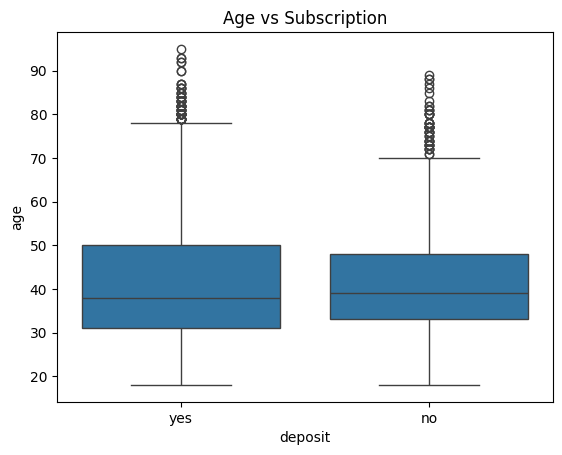

In [6]:
# This analysis checks whether age influences customer subscription behavior.

sns.boxplot(x='deposit', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()

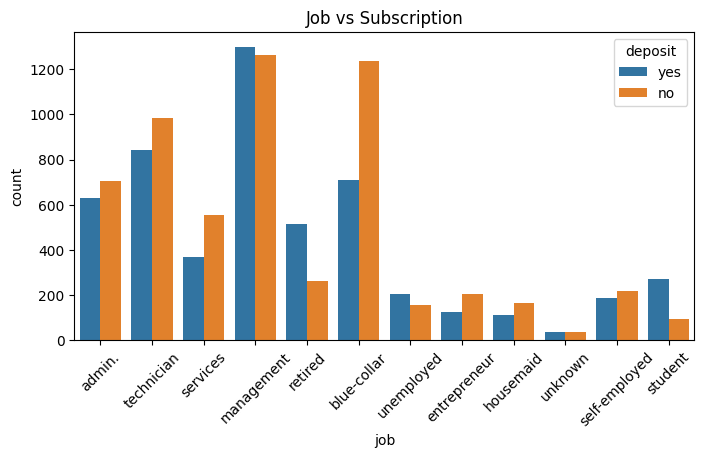

In [9]:
# This shows which job categories respond better to marketing campaigns.

plt.figure(figsize=(8,4))
Chart = sns.countplot(x='job', hue='deposit', data=df)
plt.title("Job vs Subscription")
plt.xticks(rotation=45)
plt.show()

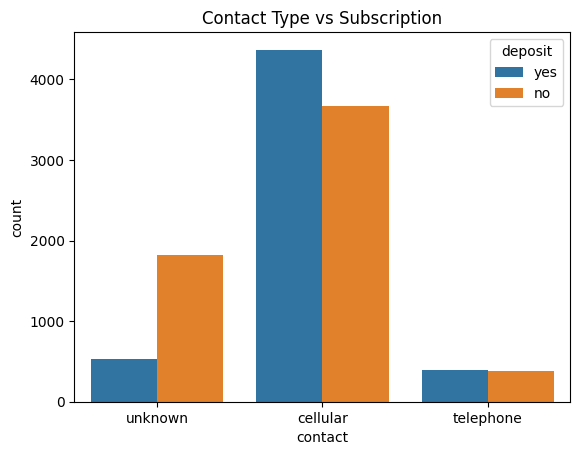

In [12]:
# This helps identify which communication method is more effective.

sns.countplot(x='contact', hue='deposit', data=df)
plt.title("Contact Type vs Subscription")
plt.show()

##Encode Categorical Variables

In [13]:
# Categorical features are converted into numerical format for model training.
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


##Feature Selection

In [15]:
# Features and target variable are separated for model building.
X = df.drop('deposit', axis=1)
y = df['deposit']

##Train-Test Split

In [17]:
# The dataset is split to evaluate model performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Model 1 – Logistic Regression

In [19]:
# Logistic regression is used as a baseline model for classification.

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##Model 2 – Random Forest

In [20]:
# Random Forest captures complex relationships and improves prediction performance.
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

##Model Evaluation

In [21]:
# Model performance is evaluated using classification metrics.
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1166
           1       0.78      0.76      0.77      1067

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1166
           1       0.80      0.86      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



##ROC Curve

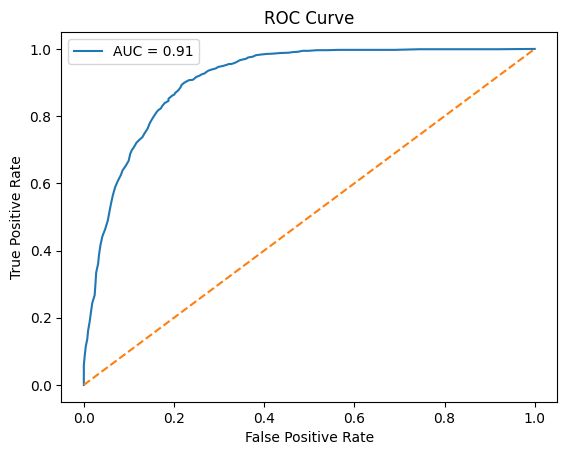

In [22]:
# ROC curve evaluates model performance across different classification thresholds.
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()

##SHAP

In [30]:
# SHAP helps explain which features influence the model predictions.
!pip install shap

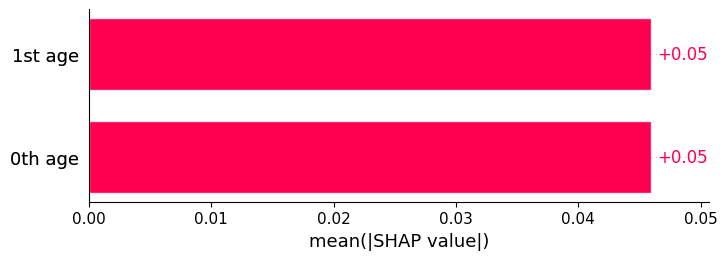

In [32]:
import shap

# For tree-based models like RandomForest, TreeExplainer is efficient.
# It's common for explainer.shap_values to return a list of arrays for binary classification,
# where each array corresponds to the SHAP values for a specific class.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values will be a list of two arrays.
# shap_values[0] for class 0 (no deposit), shap_values[1] for class 1 (deposit).
# We typically plot the SHAP values for the positive class (class 1).
# Create a shap.Explanation object for the positive class to ensure feature names are correctly associated.
explanation_for_plot = shap.Explanation(
    values=shap_values[1],  # SHAP values for the positive class (deposit)
    base_values=explainer.expected_value[1], # Base value for the positive class
    data=X_test.values,      # Original data as numpy array
    feature_names=X_test.columns.tolist() # Feature names from the DataFrame
)

# Plot the SHAP values for the positive class
# Added max_display for better visualization, showing the top 15 features.
shap.plots.bar(explanation_for_plot, max_display=15)

##Conclusion
This project demonstrates how machine learning can predict customer subscription behavior.
Random Forest performed better than Logistic Regression, capturing complex patterns in the data.

Explainable AI techniques such as SHAP provide insights into key factors influencing
customer decisions, helping banks design more effective marketing strategies.